In [31]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential , Model 
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2 , VGG16
from tensorflow.keras.optimizers import Adam

import os
import random

import warnings
warnings.filterwarnings('ignore')

In [32]:
# ====================================================================
# 🌐 DATASET AUTO-RESOLVER & KAGGLE CONNECTOR (CT Kidney Dataset)
# ====================================================================
import os

data_path = None

def find_kidney_dir(search_root):
    if not os.path.exists(search_root):
        return None
    for root, dirs, _ in os.walk(search_root):
        dirs_lower = [d.lower() for d in dirs]
        if any('stone' in d or 'cyst' in d or 'tumor' in d for d in dirs_lower):
            # check if it has multiple disease classes
            if len(dirs) >= 3:
                return root
    return None

search_locations = ['/kaggle/input', '../input', '../datasets', './datasets', '.']
for loc in search_locations:
    found = find_kidney_dir(loc)
    if found:
        data_path = found
        print(f'✅ Found CT Kidney dataset at: {data_path}')
        break

if not data_path:
    print('⚡ Dataset not detected in mounted inputs. Downloading via KaggleHub...')
    try:
        import kagglehub
        download_path = kagglehub.dataset_download('nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone')
        print(f'✅ Downloaded to: {download_path}')
        data_path = find_kidney_dir(download_path)
    except Exception as e:
        print(f'⚠️ KaggleHub auto-download notice: {e}')

if not data_path:
    data_path = '/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'

print(f'📂 Resolved data_path: {data_path}')

# Set seed for reproducibility
seed = 123

# Create the train dataset with a validation split
train_ds = keras.utils.image_dataset_from_directory(
    data_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150),
    validation_split=0.2,
    subset='training',
    seed=seed
)

# Create the validation (test) dataset
test_ds = keras.utils.image_dataset_from_directory(
    data_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150),
    validation_split=0.2,
    subset='validation',
    seed=seed
)


⚡ Dataset not detected in mounted inputs. Downloading via KaggleHub...
✅ Downloaded to: /Users/shivammaurya/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1
📂 Resolved data_path: /Users/shivammaurya/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
Found 12446 files belonging to 4 classes.
Using 9957 files for training.
Found 12446 files belonging to 4 classes.
Using 2489 files for validation.


In [33]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [34]:
# load MobilenetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze layers 
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

In [35]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [37]:
# Training MobileNetV2
history_mobilenet = model.fit(train_ds, epochs=20, validation_data=test_ds)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 55s 167ms/step - accuracy: 0.6206 - loss: 1.0112 - val_accuracy: 0.7626 - val_loss: 0.6526
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.7775 - loss: 0.6210 - val_accuracy: 0.8449 - val_loss: 0.4721
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.8294 - loss: 0.4852 - val_accuracy: 0.8759 - val_loss: 0.3740
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.8671 - loss: 0.3957 - val_accuracy: 0.8863 - val_loss: 0.3172
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 43s 137ms/step - accuracy: 0.8898 - loss: 0.3357 - val_accuracy: 0.9080 - val_loss: 0.2649
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.8998 - loss: 0.2927 - val_accuracy: 0.9241 - val_loss: 0.2270
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9178 - loss: 0.2553 - val_accuracy: 0.9417 - val_loss: 0.1943
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.9308 - loss: 0

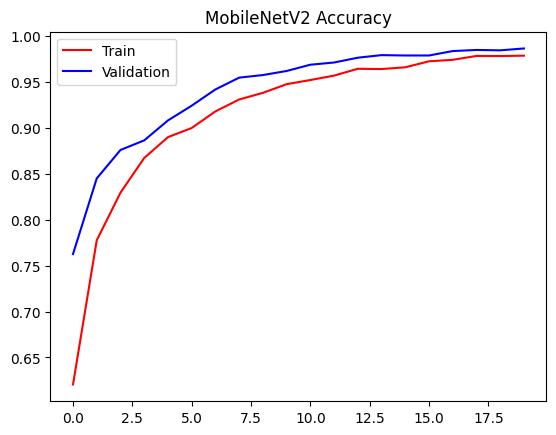

In [38]:
plt.title('MobileNetV2 Accuracy')

plt.plot(history_mobilenet.history['accuracy'], color='red',label='Train')
plt.plot(history_mobilenet.history['val_accuracy'], color='blue',label='Validation')

plt.legend()

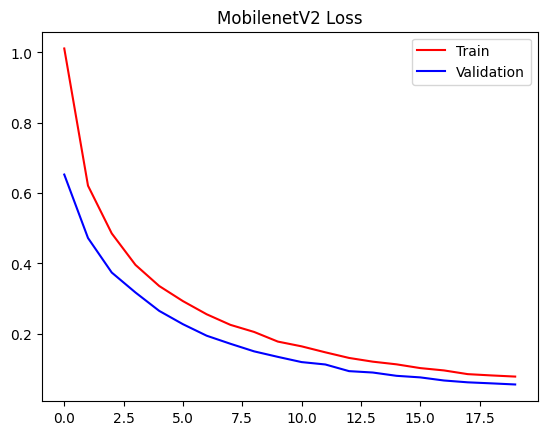

In [39]:
plt.title('MobilenetV2 Loss')

plt.plot(history_mobilenet.history['loss'], color='red',label='Train')
plt.plot(history_mobilenet.history['val_loss'], color='blue',label='Validation')

plt.legend()

In [40]:
from sklearn.metrics import classification_report, confusion_matrix

# predictions
y_pred = model.predict(test_ds)
y_pred_classes = y_pred.argmax(axis=1)  

y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

# classification report
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
print(conf_matrix)

78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       737
           1       0.99      1.00      0.99      1001
           2       0.98      0.94      0.96       280
           3       0.98      1.00      0.99       471

    accuracy                           0.99      2489
   macro avg       0.98      0.98      0.98      2489
weighted avg       0.99      0.99      0.99      2489

[[726   0   4   7]
 [  0 998   2   1]
 [  4  12 262   2]
 [  1   1   0 469]]


2026-10-05 13:09:22.486606: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


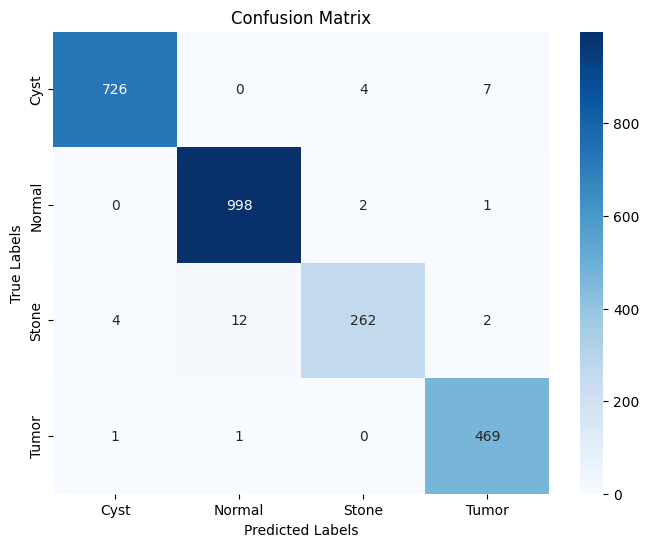

In [41]:
classes = ["Cyst", "Normal", "Stone", "Tumor"]

# สร้าง Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [42]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.9863 - loss: 0.0556
Test Loss: 0.0556
Test Accuracy: 0.9863


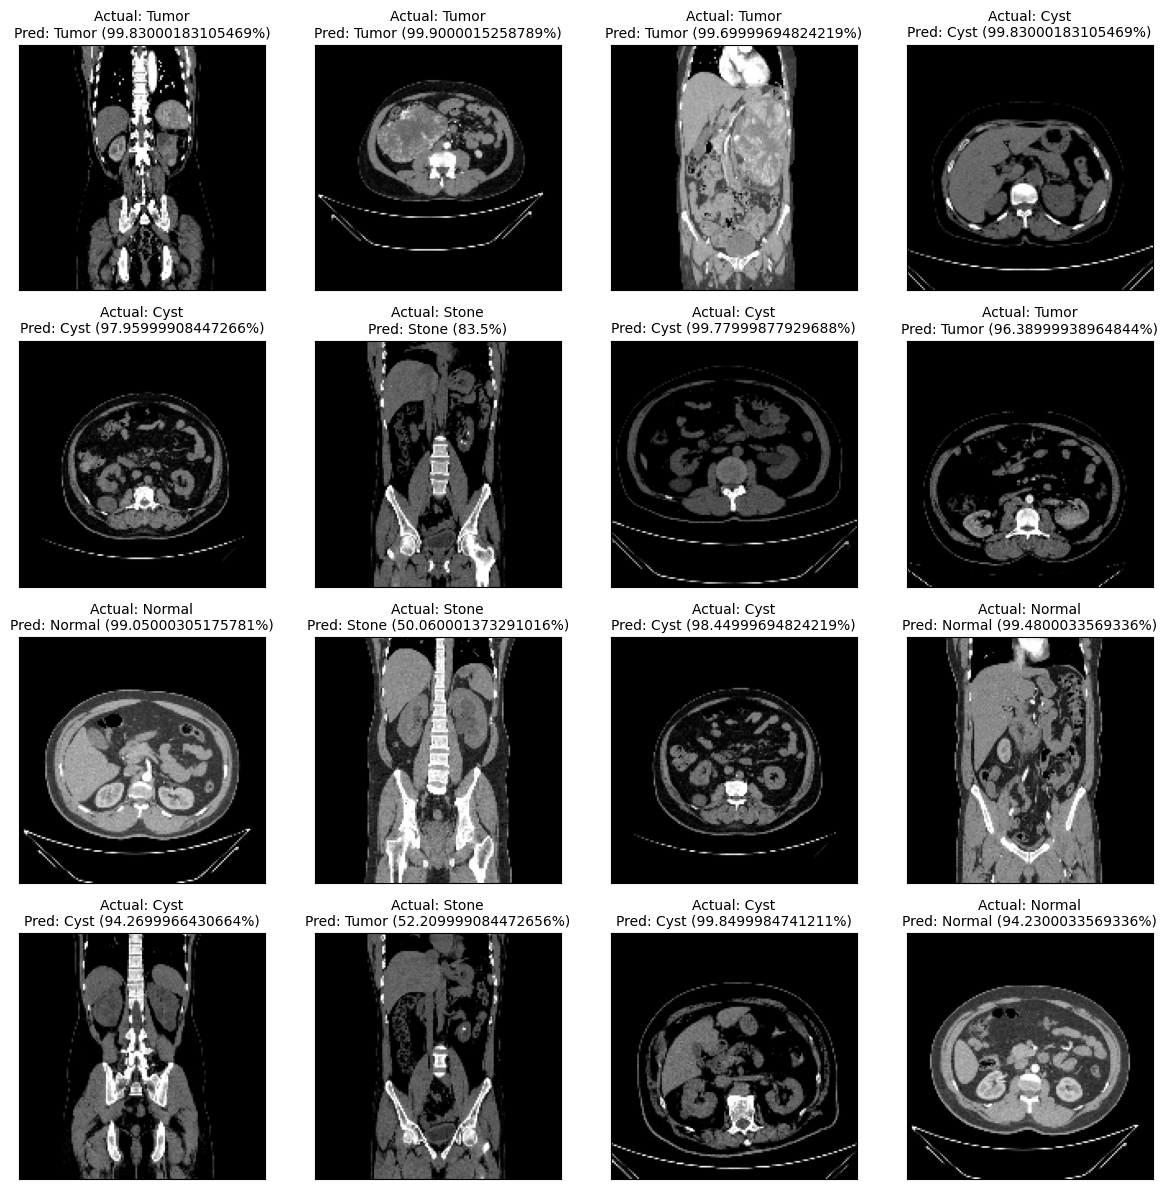

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of images and their labels from the test set
imgs, clss = next(iter(test_ds.take(1)))

# Make predictions on the batch
pred_prob = np.squeeze(model.predict(imgs, verbose=0))

# Get the predicted class indices
pred_cls = np.argmax(pred_prob, axis=1)

# Class names
class_names = ["Cyst", "Normal", "Stone", "Tumor"]

# Create subplots for displaying images
fig, ax = plt.subplots(4, 4, figsize=(12, 12))
ax = ax.flatten()

# Loop through each image in the batch and display it with predicted and actual class
for i, img in enumerate(imgs[:16]):
    ax[i].imshow(img.numpy().astype("uint8"))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    # Set the title with the actual and predicted class names, and the prediction probability
    actual_class = clss[i].numpy()
    ax[i].set_title(f'Actual: {class_names[actual_class]}\n'
                     f'Pred: {class_names[pred_cls[i]]} ({round(np.max(pred_prob[i]) * 100, 2)}%)', fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [44]:
from tensorflow.keras.applications import EfficientNetB0

# Load EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze layers
base_model.trainable = False

# Build the custom model on top of EfficientNetB0
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)


In [45]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 150, 150,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 150, 150,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 150, 150,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 151, 151,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 75, 75,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 75, 75,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 75, 75,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 75, 75,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 75, 75,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 75, 75,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 75, 75,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 75, 75,    │        512 │ block1a_se_excit

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [46]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Training EfficientNetB0
history_efficientnet = model.fit(train_ds, epochs=40, validation_data=test_ds)

Epoch 1/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 60s 178ms/step - accuracy: 0.6090 - loss: 0.9866 - val_accuracy: 0.7674 - val_loss: 0.6467
Epoch 2/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.7700 - loss: 0.6395 - val_accuracy: 0.8365 - val_loss: 0.4728
Epoch 3/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.8227 - loss: 0.5046 - val_accuracy: 0.8819 - val_loss: 0.3725
Epoch 4/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 175ms/step - accuracy: 0.8612 - loss: 0.4170 - val_accuracy: 0.9104 - val_loss: 0.3060
Epoch 5/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 62s 200ms/step - accuracy: 0.8834 - loss: 0.3558 - val_accuracy: 0.9277 - val_loss: 0.2572
Epoch 6/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 63s 203ms/step - accuracy: 0.9021 - loss: 0.3089 - val_accuracy: 0.9401 - val_loss: 0.2182
Epoch 7/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step - accuracy: 0.9174 - loss: 0.2706 - val_accuracy: 0.9454 - val_loss: 0.1909
Epoch 8/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.9309 - loss: 0

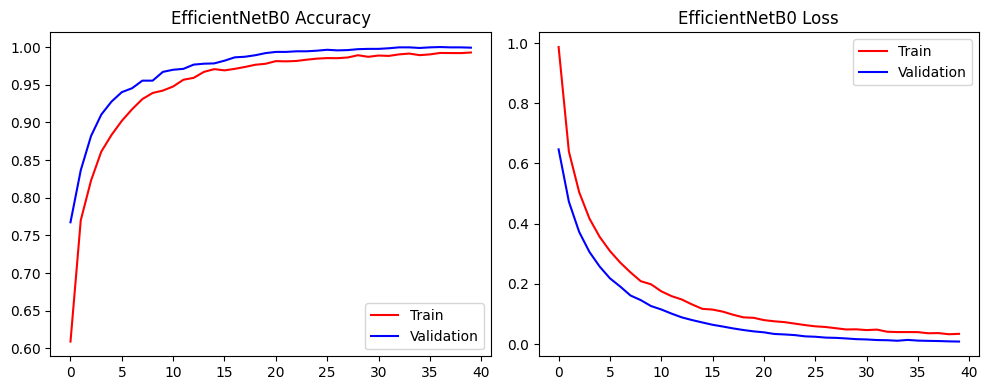

In [47]:
plt.figure(figsize=(10, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.title('EfficientNetB0 Accuracy')
plt.plot(history_efficientnet.history['accuracy'], color='red', label='Train')
plt.plot(history_efficientnet.history['val_accuracy'], color='blue', label='Validation')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.title('EfficientNetB0 Loss')
plt.plot(history_efficientnet.history['loss'], color='red', label='Train')
plt.plot(history_efficientnet.history['val_loss'], color='blue', label='Validation')
plt.legend()

plt.tight_layout()
plt.show()


In [48]:
# Evaluate the EfficientNet model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.9992 - loss: 0.0082
Test Loss: 0.0082
Test Accuracy: 0.9992


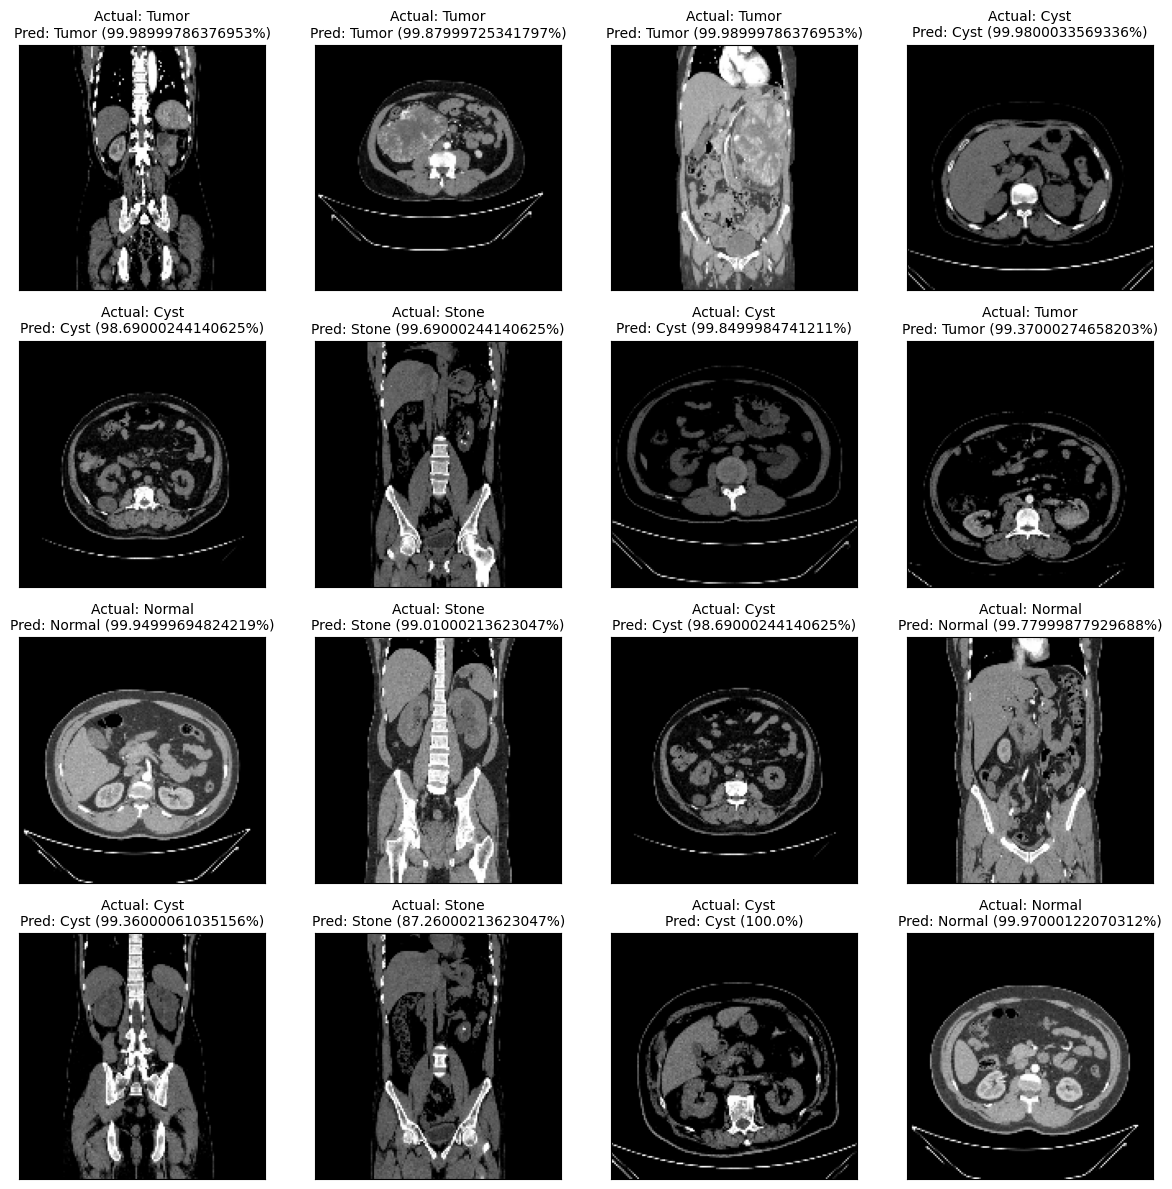

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of images and their labels from the test set
imgs, clss = next(iter(test_ds.take(1)))

# Make predictions on the batch
pred_prob = np.squeeze(model.predict(imgs, verbose=0))

# Get the predicted class indices
pred_cls = np.argmax(pred_prob, axis=1)

# Class names
class_names = ["Cyst", "Normal", "Stone", "Tumor"]

# Create subplots for displaying images
fig, ax = plt.subplots(4, 4, figsize=(12, 12))
ax = ax.flatten()

# Loop through each image in the batch and display it with predicted and actual class
for i, img in enumerate(imgs[:16]):
    ax[i].imshow(img.numpy().astype("uint8"))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    # Set the title with the actual and predicted class names, and the prediction probability
    actual_class = clss[i].numpy()
    ax[i].set_title(f'Actual: {class_names[actual_class]}\n'
                     f'Pred: {class_names[pred_cls[i]]} ({round(np.max(pred_prob[i]) * 100, 2)}%)', fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


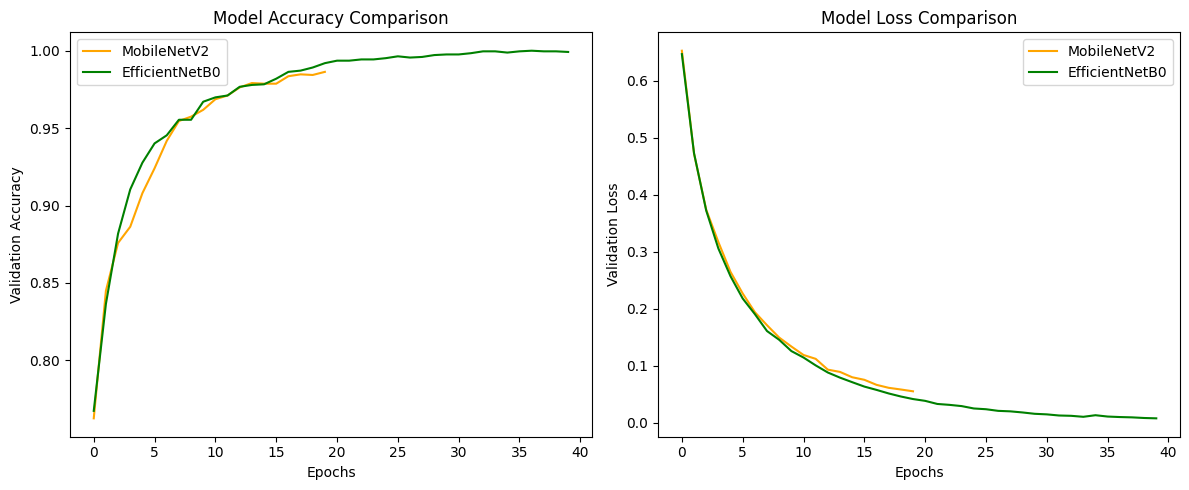

In [50]:
# Plot accuracy comparison
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.title("Model Accuracy Comparison")
plt.plot(history_mobilenet.history['val_accuracy'], color='orange', label='MobileNetV2')
plt.plot(history_efficientnet.history['val_accuracy'], color='green', label='EfficientNetB0')
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.title("Model Loss Comparison")
plt.plot(history_mobilenet.history['val_loss'], color='orange', label='MobileNetV2')
plt.plot(history_efficientnet.history['val_loss'], color='green', label='EfficientNetB0')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [51]:
def build_unet(input_shape=(150, 150, 3), num_classes=4):
    inputs = keras.Input(shape=input_shape)
    
    # Encoder block 1
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = MaxPooling2D((2, 2))(c1)
    
    # Encoder block 2
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    c2 = BatchNormalization()(c2)
    c2 = MaxPooling2D((2, 2))(c2)
    
    # Bridge
    b = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    b = BatchNormalization()(b)

    # Global pooling instead of upsampling
    x = GlobalAveragePooling2D()(b)
    x = Dropout(0.5)(x)
    
    # Classification head
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


In [52]:
unet_model = build_unet()
unet_model.compile(optimizer=Adam(learning_rate=0.0001),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
history_unet = unet_model.fit(train_ds, epochs=40, validation_data=test_ds)

Epoch 1/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 101s 316ms/step - accuracy: 0.6359 - loss: 0.9488 - val_accuracy: 0.6963 - val_loss: 0.8201
Epoch 2/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 99s 316ms/step - accuracy: 0.7369 - loss: 0.6869 - val_accuracy: 0.7963 - val_loss: 0.6289
Epoch 3/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.7926 - loss: 0.5708 - val_accuracy: 0.8100 - val_loss: 0.5618
Epoch 4/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.8252 - loss: 0.4885 - val_accuracy: 0.8345 - val_loss: 0.4746
Epoch 5/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 105s 336ms/step - accuracy: 0.8482 - loss: 0.4268 - val_accuracy: 0.8738 - val_loss: 0.3683
Epoch 6/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 104s 332ms/step - accuracy: 0.8705 - loss: 0.3755 - val_accuracy: 0.8943 - val_loss: 0.3176
Epoch 7/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 102s 326ms/step - accuracy: 0.8875 - loss: 0.3325 - val_accuracy: 0.9112 - val_loss: 0.2735
Epoch 8/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 103s 332ms/step - accuracy: 0.9028 - l

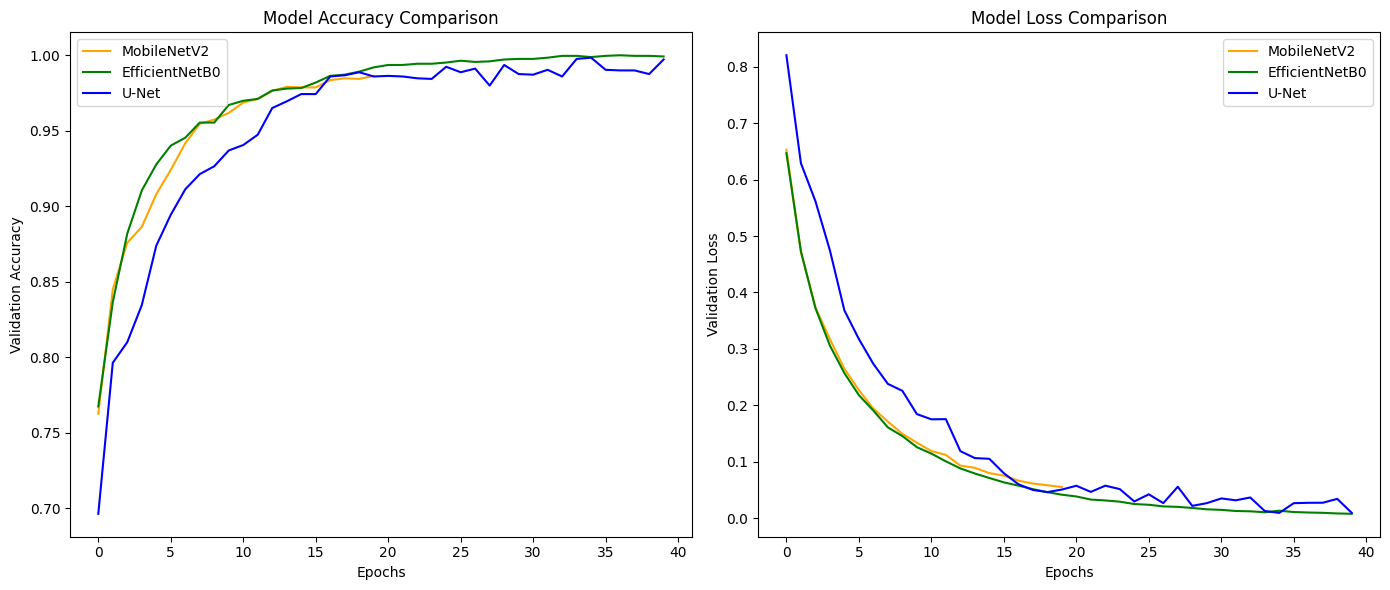

In [53]:
# Comparison Plot
plt.figure(figsize=(14, 6))

# Accuracy Comparison
plt.subplot(1, 2, 1)
plt.title("Model Accuracy Comparison")
plt.plot(history_mobilenet.history['val_accuracy'], color='orange', label='MobileNetV2')
plt.plot(history_efficientnet.history['val_accuracy'], color='green', label='EfficientNetB0')
plt.plot(history_unet.history['val_accuracy'], color='blue', label='U-Net')
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()

# Loss Comparison
plt.subplot(1, 2, 2)
plt.title("Model Loss Comparison")
plt.plot(history_mobilenet.history['val_loss'], color='orange', label='MobileNetV2')
plt.plot(history_efficientnet.history['val_loss'], color='green', label='EfficientNetB0')
plt.plot(history_unet.history['val_loss'], color='blue', label='U-Net')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step
U-Net Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       737
           1       1.00      1.00      1.00      1001
           2       1.00      0.99      1.00       280
           3       1.00      0.99      1.00       471

    accuracy                           1.00      2489
   macro avg       1.00      1.00      1.00      2489
weighted avg       1.00      1.00      1.00      2489



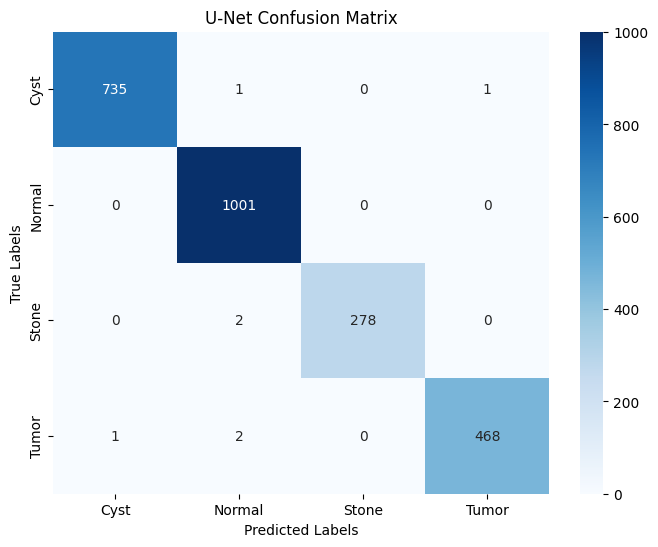

In [54]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions for U-Net
y_pred_unet = unet_model.predict(test_ds)
y_pred_classes_unet = y_pred_unet.argmax(axis=1)

# Extract true labels
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

# Classification Report
print("U-Net Classification Report:")
print(classification_report(y_true, y_pred_classes_unet))

# Confusion Matrix
conf_matrix_unet = confusion_matrix(y_true, y_pred_classes_unet)

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_unet, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("U-Net Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


## 📥 Download Trained Model & Artifacts (Kaggle)

This cell saves the trained kidney stone classification models (`kidney_stone_unet_model.keras`, `kidney_stone_unet_model.h5`, `kidney_stone_efficientnet_model.keras`), class mapping (`kidney_stone_classes.json`), creates a zip bundle, and displays direct download links.

In [56]:
# ====================================================================
# 📥 SAVE & DOWNLOAD TRAINED ARTIFACTS ON KAGGLE
# ====================================================================
import os
import json
import zipfile
from IPython.display import FileLink, display

saved_files = []

# 1. Save U-Net Model (both modern .keras and .h5 formats)
if 'unet_model' in globals():
    unet_keras = 'kidney_stone_unet_model.keras'
    unet_h5 = 'kidney_stone_unet_model.h5'
    unet_model.save(unet_keras)
    unet_model.save(unet_h5)
    saved_files.extend([unet_keras, unet_h5])
    print(f"✓ Saved U-Net model: {unet_keras} and {unet_h5}")

# 2. Save EfficientNet / CNN model if present in session
if 'model' in globals():
    eff_keras = 'kidney_stone_efficientnet_model.keras'
    eff_h5 = 'kidney_stone_efficientnet_model.h5'
    model.save(eff_keras)
    model.save(eff_h5)
    saved_files.extend([eff_keras, eff_h5])
    print(f"✓ Saved CNN model: {eff_keras} and {eff_h5}")

# 3. Save class names mapping
target_classes = globals().get('classes', globals().get('class_names', ["Cyst", "Normal", "Stone", "Tumor"]))
classes_file = 'kidney_stone_classes.json'
with open(classes_file, 'w') as f:
    json.dump({i: name for i, name in enumerate(target_classes)}, f, indent=2)
saved_files.append(classes_file)
print(f"✓ Saved class mapping: {classes_file}")

# 4. Package all files into a single ZIP archive for 1-click download
zip_filename = 'kidney_stone_artifacts.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file_name in saved_files:
        if os.path.exists(file_name):
            zipf.write(file_name, os.path.basename(file_name))
print(f"✓ Packaged bundle: {zip_filename}")

# 5. Generate Kaggle Direct Download Links
print("\n" + "="*50)
print("👉 Click the link below to download your complete model bundle:")
print("="*50)
display(FileLink(zip_filename))

print("\nIndividual file downloads:")
for file_name in saved_files:
    if os.path.exists(file_name):
        display(FileLink(file_name))


✓ Saved U-Net model: kidney_stone_unet_model.keras and kidney_stone_unet_model.h5
✓ Saved CNN model: kidney_stone_efficientnet_model.keras and kidney_stone_efficientnet_model.h5
✓ Saved class mapping: kidney_stone_classes.json
✓ Packaged bundle: kidney_stone_artifacts.zip

👉 Click the link below to download your complete model bundle:


/Users/shivammaurya/Desktop/Projects/Disease_Analizer/notebooks/kidney_stone_artifacts.zip


Individual file downloads:


/Users/shivammaurya/Desktop/Projects/Disease_Analizer/notebooks/kidney_stone_unet_model.keras

/Users/shivammaurya/Desktop/Projects/Disease_Analizer/notebooks/kidney_stone_unet_model.h5

/Users/shivammaurya/Desktop/Projects/Disease_Analizer/notebooks/kidney_stone_efficientnet_model.keras

/Users/shivammaurya/Desktop/Projects/Disease_Analizer/notebooks/kidney_stone_efficientnet_model.h5

/Users/shivammaurya/Desktop/Projects/Disease_Analizer/notebooks/kidney_stone_classes.json

In [57]:
# ====================================================================
# 💾 SAVE & DOWNLOAD TRAINED ARTIFACTS (Kidney Stone & Pathology)
# ====================================================================
import os
import json
import zipfile
from IPython.display import FileLink, display

# 1. Create local repository models directory if available
os.makedirs('../models/kidney_model', exist_ok=True)
os.makedirs('../models', exist_ok=True)

saved_files = []

# 2. Save U-Net Model (both native .keras and .h5 formats)
if 'unet_model' in globals():
    unet_keras = 'kidney_stone_unet_model.keras'
    unet_h5 = 'kidney_stone_unet_model.h5'
    unet_model.save(unet_keras)
    unet_model.save(unet_h5)
    saved_files.extend([unet_keras, unet_h5])
    
    # Mirror to repo models directory
    try:
        unet_model.save('../models/kidney_stone_unet_model.keras')
        unet_model.save('../models/kidney_model/kidney_stone_unet_model.keras')
    except Exception:
        pass
    print(f"✅ Saved U-Net model: {unet_keras} and {unet_h5}")

# 3. Save EfficientNet / MobileNet Model
if 'model' in globals():
    eff_keras = 'kidney_stone_efficientnet_model.keras'
    eff_h5 = 'kidney_stone_efficientnet_model.h5'
    model.save(eff_keras)
    model.save(eff_h5)
    saved_files.extend([eff_keras, eff_h5])
    
    # Mirror to repo models directory
    try:
        model.save('../models/kidney_stone_efficientnet_model.keras')
        model.save('../models/kidney_model/kidney_stone_efficientnet_model.keras')
    except Exception:
        pass
    print(f"✅ Saved CNN model: {eff_keras} and {eff_h5}")

# 4. Save Class Names / Label Index Mapping
target_classes = globals().get('classes', globals().get('class_names', ["Cyst", "Normal", "Stone", "Tumor"]))
classes_file = 'kidney_stone_classes.json'
with open(classes_file, 'w') as f:
    json.dump({i: name for i, name in enumerate(target_classes)}, f, indent=2)
saved_files.append(classes_file)

try:
    with open('../models/kidney_stone_classes.json', 'w') as f:
        json.dump({i: name for i, name in enumerate(target_classes)}, f, indent=2)
except Exception:
    pass

print(f"✅ Saved class index mapping: {classes_file}")

# 5. Package all artifacts into a single ZIP archive
zip_filename = 'kidney_stone_artifacts.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_name in saved_files:
        if os.path.exists(file_name):
            zipf.write(file_name, os.path.basename(file_name))
            print(f"   📦 Packaged: {file_name} ({os.path.getsize(file_name)} bytes)")

print(f"\n🎉 All artifacts packaged successfully into: {zip_filename}")
print(f"📊 Total Archive Size: {os.path.getsize(zip_filename) / (1024*1024):.2f} MB")

# 6. Generate Direct Clickable Download Links
print("\n" + "="*50)
print("👉 Click the link below to download your complete model bundle:")
print("="*50)
display(FileLink(zip_filename))


✅ Saved U-Net model: kidney_stone_unet_model.keras and kidney_stone_unet_model.h5
✅ Saved CNN model: kidney_stone_efficientnet_model.keras and kidney_stone_efficientnet_model.h5
✅ Saved class index mapping: kidney_stone_classes.json
   📦 Packaged: kidney_stone_unet_model.keras (1396986 bytes)
   📦 Packaged: kidney_stone_unet_model.h5 (1401088 bytes)
   📦 Packaged: kidney_stone_efficientnet_model.keras (19016268 bytes)
   📦 Packaged: kidney_stone_efficientnet_model.h5 (18906736 bytes)
   📦 Packaged: kidney_stone_classes.json (66 bytes)

🎉 All artifacts packaged successfully into: kidney_stone_artifacts.zip
📊 Total Archive Size: 34.52 MB

👉 Click the link below to download your complete model bundle:


/Users/shivammaurya/Desktop/Projects/Disease_Analizer/notebooks/kidney_stone_artifacts.zip